In [1]:
# Importing required libraries
import pandas as pd
import numpy as np

# Libraries for machine learning
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, 
    roc_auc_score, 
    confusion_matrix,
    precision_recall_curve,
    average_precision_score,
    f1_score
)

# For plots
import matplotlib.pyplot as plt
import seaborn as sns

import pickle
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

print("Libraries imported successfully")

Libraries imported successfully


# Dataset Exploration

Dataset shape: (500000, 34)

First few rows:
   user_id            timestamp merchant location  amount  amount_log  \
0      120  2024-01-01T08:15:00   Amazon       NY  602.02    6.401950   
1      125  2024-01-01T08:30:00   Casino      LON  566.88    6.341910   
2      141  2024-01-01T08:35:00  Walmart      BLR  363.49    5.898499   
3      139  2024-01-01T08:36:00  Walmart      BLR   97.16    4.586599   
4      118  2024-01-01T08:51:00   Casino      CHI  734.32    6.600306   

   amount_zscore  amount_ratio_to_avg  is_round_amount  is_very_high  ...  \
0            0.0                  1.0                0             0  ...   
1            0.0                  1.0                0             0  ...   
2            0.0                  1.0                0             0  ...   
3            0.0                  1.0                0             0  ...   
4            0.0                  1.0                0             0  ...   

   distance_from_last_tx_log  travel_speed  travel_sp

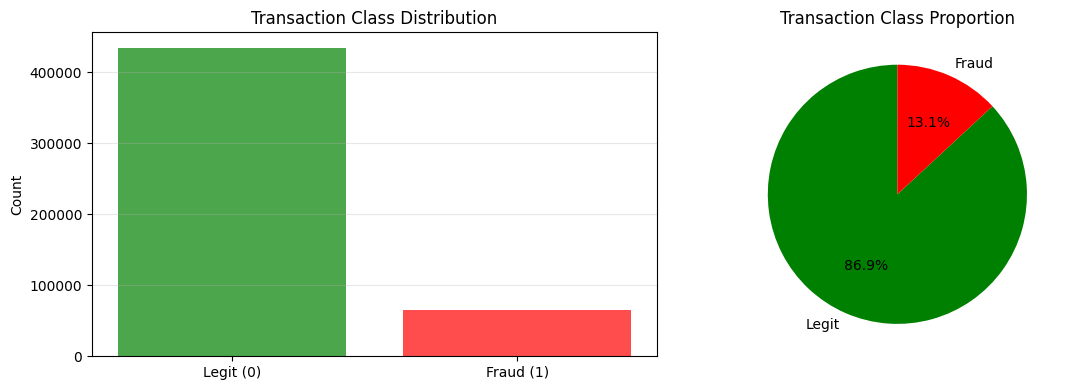


Data loaded: 500,000 transactions
Fraud rate: 13.11%


In [2]:
df = pd.read_csv("/kaggle/input/datasets/praneeth1265/synthetic-credit-card-transactions-fraud-detection/fraud_dataset_5l.csv")

# Sorting by timestamp becuase it's time-series data
df = df.sort_values('timestamp').reset_index(drop=True)

# Basic information
print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())

print(f"\nDataset info:")
print(df.info())

# Checking class distribution
print("\n" + "="*60)
print("CLASS DISTRIBUTION")
print("="*60)
fraud_counts = df['fraud_label'].value_counts()
fraud_props = df['fraud_label'].value_counts(normalize=True) * 100

print("\nCounts:")
print(fraud_counts)
print("\nProportions (%):")
print(fraud_props)

# Visualisual representation of class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
axes[0].bar(['Legit (0)', 'Fraud (1)'], fraud_counts.values, color=['green', 'red'], alpha=0.7)
axes[0].set_ylabel('Count')
axes[0].set_title('Transaction Class Distribution')
axes[0].grid(axis='y', alpha=0.3)

# Proportion plot
axes[1].pie(fraud_counts.values, labels=['Legit', 'Fraud'], autopct='%1.1f%%', 
            colors=['green', 'red'], startangle=90)
axes[1].set_title('Transaction Class Proportion')

plt.tight_layout()
plt.show()

print(f"\nData loaded: {len(df):,} transactions")
print(f"Fraud rate: {df['fraud_label'].mean():.2%}")

# Features Setup for model

In [3]:
# Defining Feature columns
feature_columns = [
    # Amount features
    'amount', 'amount_log', 'amount_zscore', 'amount_ratio_to_avg',
    'is_round_amount', 'is_very_high',
    
    # Time features
    'hour', 'day_of_week', 'is_weekend', 'is_night',
    'hours_since_last_tx', 'hours_since_last_tx_log', 'is_rapid_tx',
    
    # Velocity Features
    'tx_count_1h', 'tx_count_24h', 'total_tx_count', 'is_first_tx',
    
    # Location features
    'location_mismatch_home', 'location_mismatch_last',
    'distance_from_last_tx', 'distance_from_last_tx_log',
    'travel_speed', 'travel_speed_log', 'is_impossible_travel',
    'location_frequency', 'is_new_location',
    
    # Merchant features
    'merchant_risk', 'merchant_frequency', 'is_new_merchant'
]

# Separate features and target
X = df[feature_columns]
y = df['fraud_label']

print(f"Features defined: {len(feature_columns)} features")
print(f"feature matrix shape: {X.shape}")
print(f"\nfeature list:")
for i, feature in enumerate(feature_columns, 1):
    print(f"  {i:2d}. {feature}")

Features defined: 29 features
feature matrix shape: (500000, 29)

feature list:
   1. amount
   2. amount_log
   3. amount_zscore
   4. amount_ratio_to_avg
   5. is_round_amount
   6. is_very_high
   7. hour
   8. day_of_week
   9. is_weekend
  10. is_night
  11. hours_since_last_tx
  12. hours_since_last_tx_log
  13. is_rapid_tx
  14. tx_count_1h
  15. tx_count_24h
  16. total_tx_count
  17. is_first_tx
  18. location_mismatch_home
  19. location_mismatch_last
  20. distance_from_last_tx
  21. distance_from_last_tx_log
  22. travel_speed
  23. travel_speed_log
  24. is_impossible_travel
  25. location_frequency
  26. is_new_location
  27. merchant_risk
  28. merchant_frequency
  29. is_new_merchant


# Dataset Split

In [4]:
# Time-based split: Train (60%) -> Validation (20%) -> Test (20%)
train_ratio = 0.6
val_ratio = 0.2
test_ratio = 0.2

train_idx = int(len(df) * train_ratio)
val_idx = int(len(df) * (train_ratio + val_ratio))

X_train = X.iloc[:train_idx]
X_val = X.iloc[train_idx:val_idx]
X_test = X.iloc[val_idx:]

y_train = y.iloc[:train_idx]
y_val = y.iloc[train_idx:val_idx]
y_test = y.iloc[val_idx:]

print("="*60)
print("TRAIN-VALIDATION-TEST SPLIT (Time-Based)")
print("="*60)

print(f"\nTraining Set:")
print(f"  - Total samples: {len(X_train):,}")
print(f"  - Fraud samples: {y_train.sum():,}")
print(f"  - Legit samples: {(y_train == 0).sum():,}")
print(f"  - Fraud rate: {y_train.mean():.2%}")

print(f"\nValidation Set:")
print(f"  - Total samples: {len(X_val):,}")
print(f"  - Fraud samples: {y_val.sum():,}")
print(f"  - Legit samples: {(y_val == 0).sum():,}")
print(f"  - Fraud rate: {y_val.mean():.2%}")

print(f"\nTest Set:")
print(f"  - Total samples: {len(X_test):,}")
print(f"  - Fraud samples: {y_test.sum():,}")
print(f"  - Legit samples: {(y_test == 0).sum():,}")
print(f"  - Fraud rate: {y_test.mean():.2%}")

print(f"\nSplit ratio: {train_ratio:.0%} train / {val_ratio:.0%} val / {test_ratio:.0%} test")

TRAIN-VALIDATION-TEST SPLIT (Time-Based)

Training Set:
  - Total samples: 300,000
  - Fraud samples: 39,173
  - Legit samples: 260,827
  - Fraud rate: 13.06%

Validation Set:
  - Total samples: 100,000
  - Fraud samples: 13,178
  - Legit samples: 86,822
  - Fraud rate: 13.18%

Test Set:
  - Total samples: 100,000
  - Fraud samples: 13,200
  - Legit samples: 86,800
  - Fraud rate: 13.20%

Split ratio: 60% train / 20% val / 20% test


In [5]:
# Calculating class imbalance ratio
fraud_count = (y_train == 1).sum()
legit_count = (y_train == 0).sum()
imbalance_ratio = legit_count / fraud_count

print("="*60)
print("CLASS IMBALANCE ANALYSIS")
print("="*60)

print(f"\nLegit transactions: {legit_count:,}")
print(f"fraud transactions: {fraud_count:,}")
print(f"imbalance ratio: {imbalance_ratio:.2f}:1")

# This tells XGBoost to give fraud samples more weight during training
print(f"\nStrategy: Using scale_pos_weight = {imbalance_ratio:.2f}")

# Storing weight for model params
scale_pos_weight = imbalance_ratio

CLASS IMBALANCE ANALYSIS

Legit transactions: 260,827
fraud transactions: 39,173
imbalance ratio: 6.66:1

Strategy: Using scale_pos_weight = 6.66


# XGBoost Setup

In [6]:
# XGBoost hyperparameters
params = {
    # Tree structure
    'max_depth': 6,                    # Maximum tree depth
    'min_child_weight': 5,             # Minimum sum of instance weight in a child
    'gamma': 0.1,                      # Minimum loss reduction for split
    
    # Boosting parameters
    'n_estimators': 300,               # Number of trees
    'learning_rate': 0.05,             # Step size shrinkage (eta)
    
    # Sampling
    'subsample': 0.8,                  # Fraction of samples per tree
    'colsample_bytree': 0.8,           # Fraction of features per tree
    'colsample_bylevel': 0.8,          # Fraction of features per level
    
    # Regularization
    'reg_alpha': 0.1,                  # L1 regularization
    'reg_lambda': 1.0,                 # L2 regularization
    
    # Class imbalance handling
    'scale_pos_weight': scale_pos_weight,  # Handle imbalanced dataset
    
    'device': 'cuda',
    
    # Other
    'random_state': 42,                # Reproducibility
    'eval_metric': 'auc',              # Evaluation metric
    'early_stopping_rounds': 30        # Stop if no improvement for 30 rounds
}

print("="*60)
print("XGBOOST CONFIGURATION")
print("="*60)

print("\nModel Parameters:")
for key, value in params.items():
    print(f"  {key:25s}: {value}")

# Initialize model
model = xgb.XGBClassifier(**params)

print("\nModel configured and ready for training")

XGBOOST CONFIGURATION

Model Parameters:
  max_depth                : 6
  min_child_weight         : 5
  gamma                    : 0.1
  n_estimators             : 300
  learning_rate            : 0.05
  subsample                : 0.8
  colsample_bytree         : 0.8
  colsample_bylevel        : 0.8
  reg_alpha                : 0.1
  reg_lambda               : 1.0
  scale_pos_weight         : 6.658336098843591
  device                   : cuda
  random_state             : 42
  eval_metric              : auc
  early_stopping_rounds    : 30

Model configured and ready for training


# XGBoost Traning

In [7]:
import time

print("="*60)
print("TRAINING XGBoost MODEL")
print("="*60)

# Preparing evaluation sets
eval_set = [
    (X_train, y_train),  # Training performance
    (X_test, y_test)     # Validation performance
]

eval_names = ['train', 'test']

# Start training
print("\nTraining started...\n")
start_time = time.time()

model.fit(
    X_train, 
    y_train,
    eval_set=eval_set,
    verbose=50  # Printing progress every 50 iterations
)

end_time = time.time()
training_time = end_time - start_time

print("\n" + "="*60)
print(f"Training completed!")
print(f"Training time: {training_time:.2f} seconds ({training_time/60:.2f} minutes)")
print(f"Best iteration: {model.best_iteration}")
print(f"Best score: {model.best_score:.4f}")
print("="*60)

TRAINING XGBoost MODEL

Training started...

[0]	validation_0-auc:0.82964	validation_1-auc:0.83627
[37]	validation_0-auc:0.84733	validation_1-auc:0.84026

Training completed!
Training time: 1.62 seconds (0.03 minutes)
Best iteration: 8
Best score: 0.8419


# Testing

In [8]:
print("="*60)
print("GENERATING PREDICTIONS")
print("="*60)

# Probability predictions
y_train_proba = model.predict_proba(X_train)[:, 1]
y_val_proba = model.predict_proba(X_val)[:, 1]
y_test_proba = model.predict_proba(X_test)[:, 1]

print(f"\nPrediction probabilities generated")
print(f"   Train predictions shape: {y_train_proba.shape}")
print(f"   Validation predictions shape: {y_val_proba.shape}")
print(f"   Test predictions shape: {y_test_proba.shape}")

GENERATING PREDICTIONS

Prediction probabilities generated
   Train predictions shape: (300000,)
   Validation predictions shape: (100000,)
   Test predictions shape: (100000,)


In [9]:
from sklearn.metrics import recall_score, precision_score, f1_score
# Find optimal threshold using VALIDATION set with recall-first approach
print("\nFinding optimal classification threshold on VALIDATION set...")
print("Strategy: Target Recall >= 0.80, then maximize Precision")

thresholds = np.arange(0.05, 0.95, 0.01)
metrics_list = []

for thresh in thresholds:
    y_pred_thresh = (y_val_proba >= thresh).astype(int)
    
    recall = recall_score(y_val, y_pred_thresh)
    precision = precision_score(y_val, y_pred_thresh, zero_division=0)
    f1 = f1_score(y_val, y_pred_thresh, zero_division=0)
    
    metrics_list.append({
        'threshold': thresh,
        'recall': recall,
        'precision': precision,
        'f1': f1
    })

metrics_df = pd.DataFrame(metrics_list)

# Filter thresholds where recall >= 0.80
high_recall_thresholds = metrics_df[metrics_df['recall'] >= 0.80]

if len(high_recall_thresholds) > 0:
    # Among high-recall thresholds, pick the one with highest precision
    optimal_idx = high_recall_thresholds['precision'].idxmax()
    optimal_threshold = high_recall_thresholds.loc[optimal_idx, 'threshold']
    optimal_recall = high_recall_thresholds.loc[optimal_idx, 'recall']
    optimal_precision = high_recall_thresholds.loc[optimal_idx, 'precision']
    optimal_f1 = high_recall_thresholds.loc[optimal_idx, 'f1']
    
    print(f"\nFound threshold with Recall >= 0.80")
    print(f"   Optimal threshold: {optimal_threshold:.2f}")
    print(f"   Recall: {optimal_recall:.4f}")
    print(f"   Precision: {optimal_precision:.4f}")
    print(f"   F1 Score: {optimal_f1:.4f}")
    
    if optimal_precision < 0.20:
        print(f"   Warning: Precision is below 0.20 - may need to adjust strategy")
else:
    # Fallback: if no threshold gives recall >= 0.80, use the one with max F1
    print(f"\nNo threshold achieved Recall >= 0.80")
    print(f"   Falling back to maximum F1 score approach")
    optimal_idx = metrics_df['f1'].idxmax()
    optimal_threshold = metrics_df.loc[optimal_idx, 'threshold']
    optimal_recall = metrics_df.loc[optimal_idx, 'recall']
    optimal_precision = metrics_df.loc[optimal_idx, 'precision']
    optimal_f1 = metrics_df.loc[optimal_idx, 'f1']
    
    print(f"   Optimal threshold: {optimal_threshold:.2f}")
    print(f"   Recall: {optimal_recall:.4f}")
    print(f"   Precision: {optimal_precision:.4f}")
    print(f"   F1 Score: {optimal_f1:.4f}")


Finding optimal classification threshold on VALIDATION set...
Strategy: Target Recall >= 0.80, then maximize Precision

Found threshold with Recall >= 0.80
   Optimal threshold: 0.51
   Recall: 0.8065
   Precision: 0.2952
   F1 Score: 0.4322


In [10]:
# Generate binary predictions using optimal threshold (found on validation set)
y_train_pred = (y_train_proba >= optimal_threshold).astype(int)
y_val_pred = (y_val_proba >= optimal_threshold).astype(int)
y_test_pred = (y_test_proba >= optimal_threshold).astype(int)

print(f"\nBinary predictions generated with threshold = {optimal_threshold:.2f}")


Binary predictions generated with threshold = 0.51


# Evaluation Metrics


MODEL PERFORMANCE EVALUATION

TRAINING SET PERFORMANCE:
----------------------------------------------------------------------
              precision    recall  f1-score   support

       Legit       0.96      0.73      0.83    260827
       Fraud       0.31      0.79      0.44     39173

    accuracy                           0.74    300000
   macro avg       0.63      0.76      0.63    300000
weighted avg       0.87      0.74      0.78    300000

ROC AUC Score: 0.8450
Average Precision: 0.4707

TEST SET PERFORMANCE:
----------------------------------------------------------------------
              precision    recall  f1-score   support

       Legit       0.96      0.71      0.82     86800
       Fraud       0.30      0.81      0.43     13200

    accuracy                           0.72    100000
   macro avg       0.63      0.76      0.62    100000
weighted avg       0.87      0.72      0.77    100000

ROC AUC Score: 0.8419
Average Precision: 0.4605

OVERFITTING CHECK:
--------

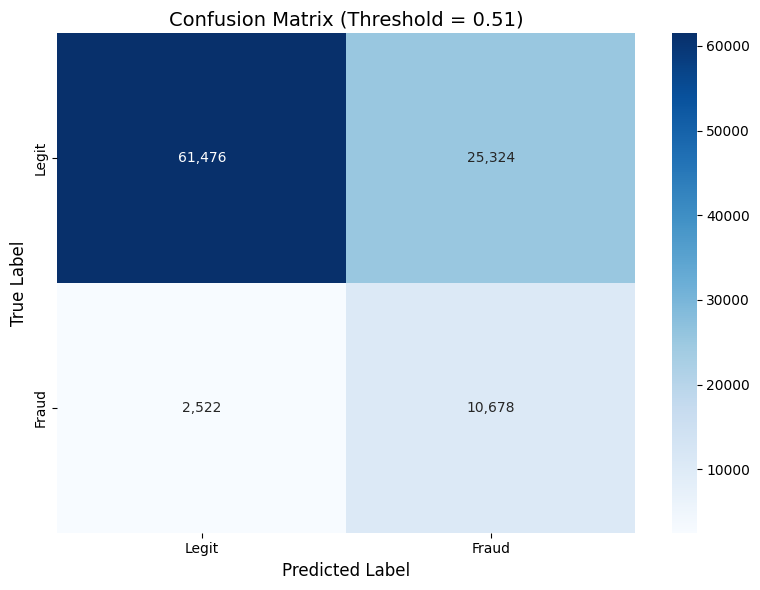

In [11]:
print("\n" + "="*70)
print("MODEL PERFORMANCE EVALUATION")
print("="*70)

# ============ TRAINING SET PERFORMANCE ============
print("\nTRAINING SET PERFORMANCE:")
print("-" * 70)
print(classification_report(y_train, y_train_pred, target_names=['Legit', 'Fraud']))

train_auc = roc_auc_score(y_train, y_train_proba)
train_ap = average_precision_score(y_train, y_train_proba)
print(f"ROC AUC Score: {train_auc:.4f}")
print(f"Average Precision: {train_ap:.4f}")

# ============ TEST SET PERFORMANCE ============
print("\n" + "="*70)
print("TEST SET PERFORMANCE:")
print("-" * 70)
print(classification_report(y_test, y_test_pred, target_names=['Legit', 'Fraud']))

test_auc = roc_auc_score(y_test, y_test_proba)
test_ap = average_precision_score(y_test, y_test_proba)
print(f"ROC AUC Score: {test_auc:.4f}")
print(f"Average Precision: {test_ap:.4f}")

# ============ OVERFITTING CHECK ============
print("\n" + "="*70)
print("OVERFITTING CHECK:")
print("-" * 70)
auc_diff = train_auc - test_auc
print(f"Train AUC: {train_auc:.4f}")
print(f"Test AUC:  {test_auc:.4f}")
print(f"Difference: {auc_diff:.4f}")

if auc_diff < 0.05:
    print("Model is generalizing well (low overfitting)")
elif auc_diff < 0.10:
    print("Slight overfitting detected")
else:
    print("High overfitting - consider more regularization")
print("\n" + "="*70)
print("CONFUSION MATRIX ANALYSIS")
print("="*70)

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
tn, fp, fn, tp = cm.ravel()

print("\nConfusion Matrix:")
print(f"\n                    Predicted")
print(f"                 Legit      Fraud")
print(f"    Legit     {tn:8,}  {fp:8,}")
print(f"    Fraud     {fn:8,}  {tp:8,}")

# Business metrics
print("\nBusiness Metrics:")
print(f"  True Negatives (Correctly flagged legit):  {tn:,}")
print(f"  False Positives (False alarms):            {fp:,}")
print(f"  False Negatives (Missed fraud):            {fn:,}")
print(f"  True Positives (Fraud caught):             {tp:,}")

print("\nKey Rates:")
fraud_detection_rate = tp / (tp + fn) if (tp + fn) > 0 else 0
false_alarm_rate = fp / (fp + tn) if (fp + tn) > 0 else 0
precision = tp / (tp + fp) if (tp + fp) > 0 else 0

print(f"  Fraud Detection Rate (Recall): {fraud_detection_rate:.2%}")
print(f"  False Alarm Rate:              {false_alarm_rate:.2%}")
print(f"  Precision (When we flag fraud): {precision:.2%}")

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', cbar=True,
            xticklabels=['Legit', 'Fraud'],
            yticklabels=['Legit', 'Fraud'])
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title(f'Confusion Matrix (Threshold = {optimal_threshold:.2f})', fontsize=14)
plt.tight_layout()
plt.show()

# Feature Importance


Top 20 Most Important Features:
                  feature  importance
            merchant_risk    0.303329
     is_impossible_travel    0.194223
                   amount    0.116336
   location_mismatch_home    0.091288
      amount_ratio_to_avg    0.051034
             travel_speed    0.043553
         travel_speed_log    0.042483
                 is_night    0.036117
               amount_log    0.025552
       merchant_frequency    0.023002
            amount_zscore    0.020180
   location_mismatch_last    0.011434
       location_frequency    0.009971
                     hour    0.008525
distance_from_last_tx_log    0.005599
    distance_from_last_tx    0.004624
              is_rapid_tx    0.004197
              tx_count_1h    0.002233
          is_new_merchant    0.001407
           total_tx_count    0.001395


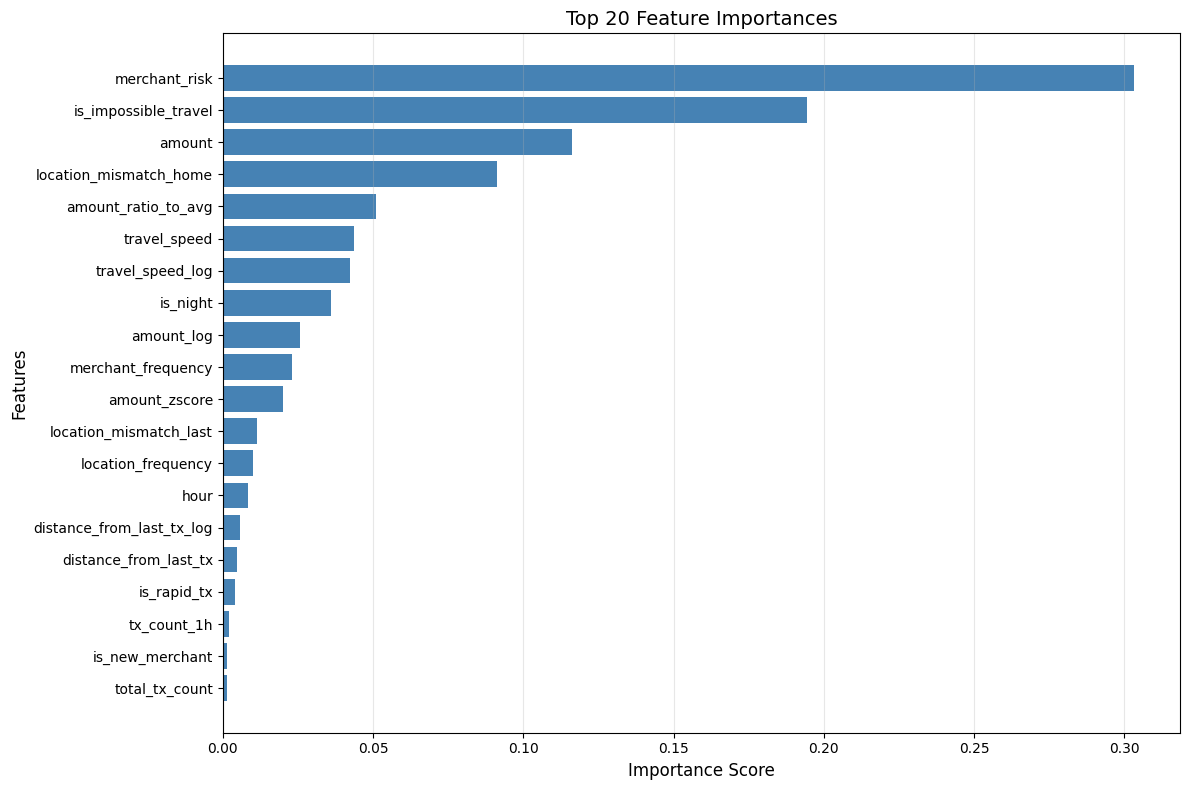


Top 10 features account for 92.7% of total importance


In [12]:
# feature importances
importance_df = pd.DataFrame({
    'feature': feature_columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 20 Most Important Features:")
print(importance_df.head(20).to_string(index=False))

# Visualizing top features
plt.figure(figsize=(12, 8))
top_n = 20
top_features = importance_df.head(top_n)

plt.barh(range(len(top_features)), top_features['importance'], color='steelblue')
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title(f'Top {top_n} Feature Importances', fontsize=14)
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Feature importance summary
total_importance = importance_df['importance'].sum()
top_10_importance = importance_df.head(10)['importance'].sum()
top_10_pct = (top_10_importance / total_importance) * 100

print(f"\nTop 10 features account for {top_10_pct:.1f}% of total importance")


CREATING VISUALIZATION DASHBOARD


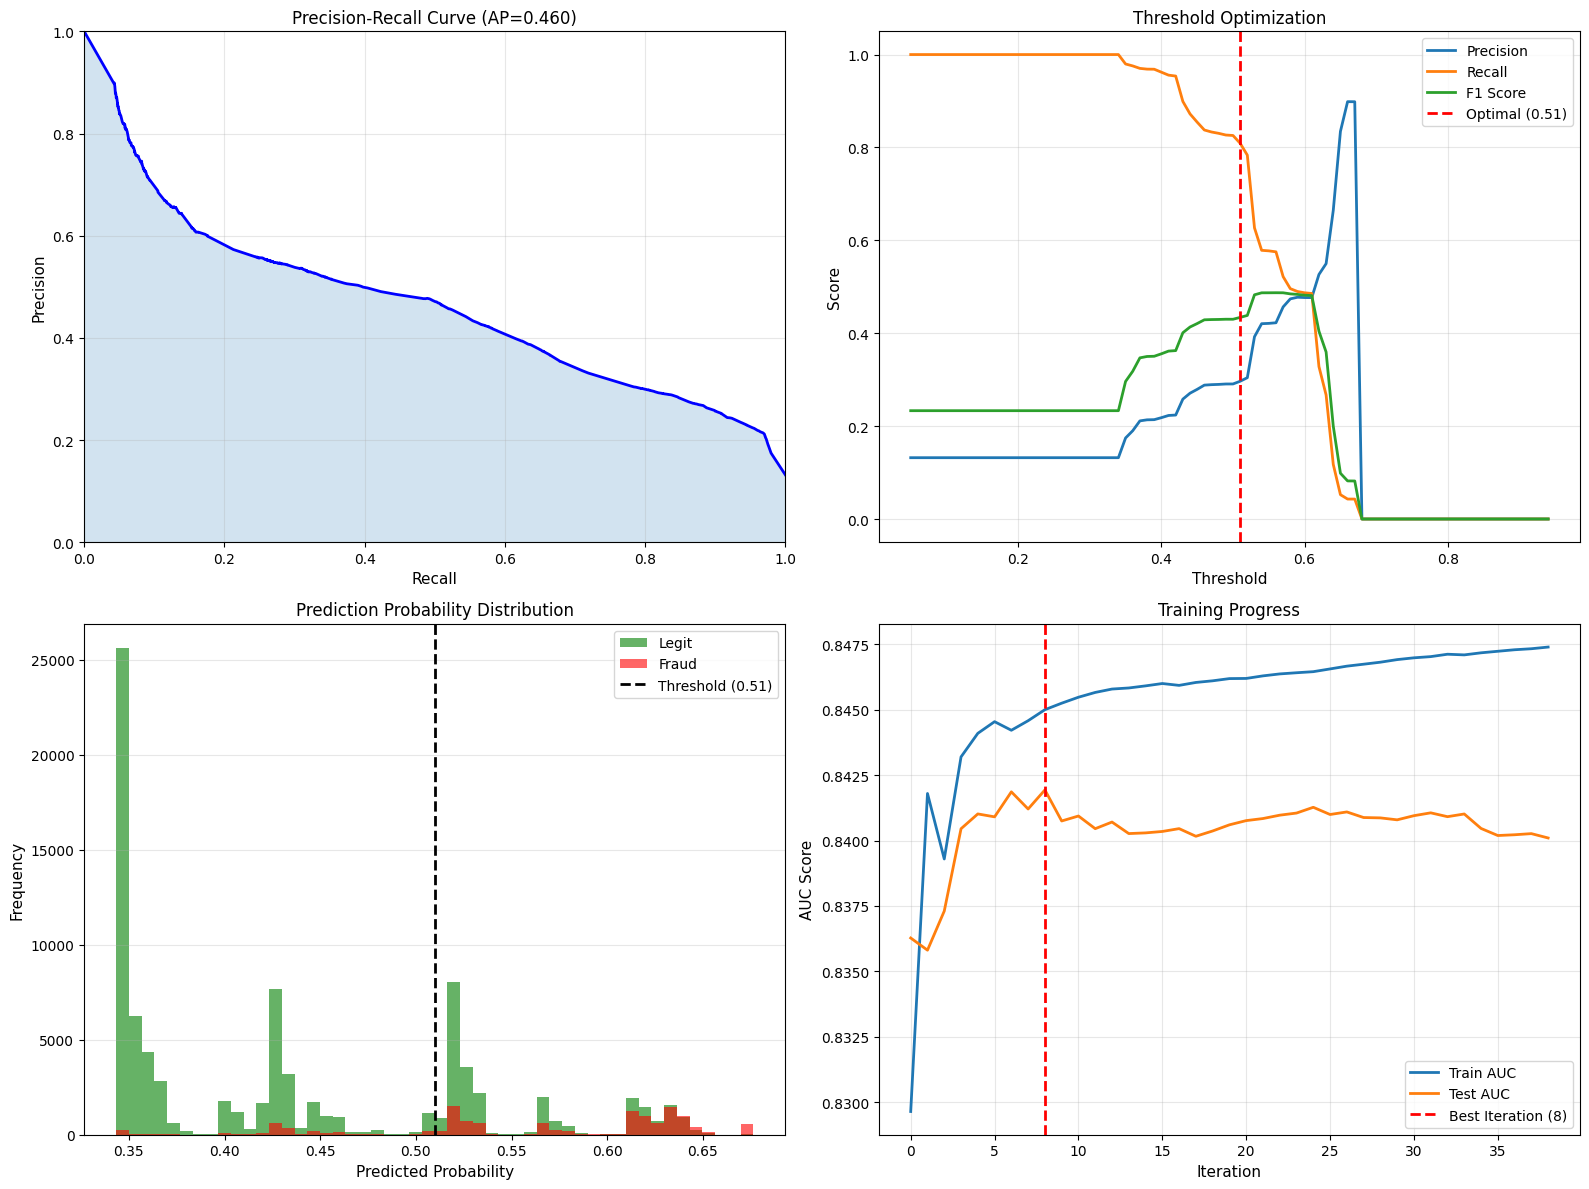

Dashboard created and saved as 'model_dashboard.png'


In [13]:
from sklearn.metrics import precision_score, recall_score
print("\n" + "="*70)
print("CREATING VISUALIZATION DASHBOARD")
print("="*70)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Precision-Recall Curve
ax1 = axes[0, 0]
precision, recall, _ = precision_recall_curve(y_test, y_test_proba)
ax1.plot(recall, precision, linewidth=2, color='blue')
ax1.fill_between(recall, precision, alpha=0.2)
ax1.set_xlabel('Recall', fontsize=11)
ax1.set_ylabel('Precision', fontsize=11)
ax1.set_title(f'Precision-Recall Curve (AP={test_ap:.3f})', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.set_xlim([0, 1])
ax1.set_ylim([0, 1])

# 2. Threshold vs Metrics
ax2 = axes[0, 1]
precision_scores = []
recall_scores = []
f1_scores_plot = []

for thresh in thresholds:
    y_pred_t = (y_test_proba >= thresh).astype(int)
    if y_pred_t.sum() > 0:  # Avoid division by zero
        p = precision_score(y_test, y_pred_t, zero_division=0)
        r = recall_score(y_test, y_pred_t, zero_division=0)
        f = f1_score(y_test, y_pred_t, zero_division=0)
        precision_scores.append(p)
        recall_scores.append(r)
        f1_scores_plot.append(f)
    else:
        precision_scores.append(0)
        recall_scores.append(0)
        f1_scores_plot.append(0)

ax2.plot(thresholds, precision_scores, label='Precision', linewidth=2)
ax2.plot(thresholds, recall_scores, label='Recall', linewidth=2)
ax2.plot(thresholds, f1_scores_plot, label='F1 Score', linewidth=2)
ax2.axvline(optimal_threshold, color='red', linestyle='--', 
            label=f'Optimal ({optimal_threshold:.2f})', linewidth=2)
ax2.set_xlabel('Threshold', fontsize=11)
ax2.set_ylabel('Score', fontsize=11)
ax2.set_title('Threshold Optimization', fontsize=12)
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)

# 3. Prediction Distribution
ax3 = axes[1, 0]
ax3.hist(y_test_proba[y_test == 0], bins=50, alpha=0.6, label='Legit', color='green')
ax3.hist(y_test_proba[y_test == 1], bins=50, alpha=0.6, label='Fraud', color='red')
ax3.axvline(optimal_threshold, color='black', linestyle='--', 
            label=f'Threshold ({optimal_threshold:.2f})', linewidth=2)
ax3.set_xlabel('Predicted Probability', fontsize=11)
ax3.set_ylabel('Frequency', fontsize=11)
ax3.set_title('Prediction Probability Distribution', fontsize=12)
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

# 4. Training Progress (Loss curves)
ax4 = axes[1, 1]
results = model.evals_result()
epochs = len(results['validation_0']['auc'])
x_axis = range(0, epochs)

ax4.plot(x_axis, results['validation_0']['auc'], label='Train AUC', linewidth=2)
ax4.plot(x_axis, results['validation_1']['auc'], label='Test AUC', linewidth=2)
ax4.axvline(model.best_iteration, color='red', linestyle='--', 
            label=f'Best Iteration ({model.best_iteration})', linewidth=2)
ax4.set_xlabel('Iteration', fontsize=11)
ax4.set_ylabel('AUC Score', fontsize=11)
ax4.set_title('Training Progress', fontsize=12)
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

print("Dashboard created and saved as 'model_dashboard.png'")

# Saving Model

In [14]:
import json
import os

print("\n" + "="*70)
print("SAVING MODEL")
print("="*70)

# Save XGBoost model as JSON
model_filename = 'fraud_detection_model.json'
model.save_model(model_filename)
print(f"✓ Model saved to: {model_filename}")

# Prepare metadata
metadata = {
    'feature_columns': feature_columns,
    'optimal_threshold': float(optimal_threshold),
    'scale_pos_weight': float(scale_pos_weight),
    'training_params': params,
    'performance': {
        'test_auc': float(test_auc),
        'test_ap': float(test_ap),
        'optimal_f1': float(optimal_f1),
        'optimal_recall': float(optimal_recall),
        'optimal_precision': float(optimal_precision),
        'fraud_detection_rate': float(fraud_detection_rate),
        'false_alarm_rate': float(false_alarm_rate)
    }
}

# Save metadata as JSON
metadata_filename = 'model_metadata.json'
with open(metadata_filename, 'w') as f:
    json.dump(metadata, f, indent=4)

print(f"✓ Metadata saved to: {metadata_filename}")

print(f"\nModel package contents:")
print(f"  - Trained XGBoost model (JSON format)")
print(f"  - {len(feature_columns)} feature names")
print(f"  - Optimal threshold: {optimal_threshold:.3f}")
print(f"  - Performance metrics")

# Print file sizes
model_size = os.path.getsize(model_filename) / (1024 * 1024)  # Convert to MB
metadata_size = os.path.getsize(metadata_filename) / 1024  # Convert to KB

print(f"\nFile sizes:")
print(f"  - Model file: {model_size:.2f} MB")
print(f"  - Metadata file: {metadata_size:.2f} KB")


SAVING MODEL
✓ Model saved to: fraud_detection_model.json
✓ Metadata saved to: model_metadata.json

Model package contents:
  - Trained XGBoost model (JSON format)
  - 29 feature names
  - Optimal threshold: 0.510
  - Performance metrics

File sizes:
  - Model file: 0.25 MB
  - Metadata file: 1.68 KB
